<center><h1> ETI195 - Ética para Ciencia de Datos y Estadística </h1><center>
<center><h2> Taller Sumativo II: Sesgos, justicia, y discriminación <h2></center>

## `Contexto`

La Encuesta de Caracterización Socioeconómica Nacional [CASEN 2024](https://observatorio.ministeriodesarrollosocial.gob.cl/encuesta-casen) cumple un rol fundamental en la toma de decisiones para la formulación de políticas sociales en Chile. Los organismos gubernamentales buscan estimar la realidad de la población, por lo que cualquier modelo predictivo construido a partir de estos datos tiene la capacidad de influir en la asignación de recursos y en la formulación de políticas públicas.

En ese sentido, un modelo que prediga la situación socioeconómica de la población puede transformarse en una herramienta con gran poder y grandes riegos como pudimos ver con el caso de SISFOH.

Como científicos de datos, a menudo nos enfrentamos a este tipo de situaciones mediante dos preguntas: ¿cómo resolver automáticamente un problema de clasificación? Y, quizás más importante, ¿qué puede salir mal cuando ese modelo toma decisiones que afectan a personas?

En este taller entrenarán un modelo predictivo de pobreza multidimensional (`pobreza_multi`) utilizando el [dataset preprocesado](https://drive.google.com/file/d/15NMlO4BD-OB55uvfYWUSCh_ba4-zCzI8/view?usp=drive_link) de la encuesta [CASEN 2024](https://observatorio.ministeriodesarrollosocial.gob.cl/encuesta-casen).

El objetivo es detectar posibles sesgos en las predicciones, evaluar si el modelo es justo para distintos grupos de la población, aplicar técnicas de mitigación y discutir los riesgos de automatizar este tipo de problemas de clasificación.

---

## Parte 1

Lea la [**Metodología de Diseño Muestral CASEN 2024**](https://drive.google.com/file/d/1VafJ57Ta6_gwUM-8sir6PAw5DVuBh0rq/view?usp=sharing), específicamente la sección *Antecedentes y características generales del diseño*, y revise el [**libro de códigos de la base de datos CASEN 2024**](https://docs.google.com/spreadsheets/d/1x25URkqJy7Ncc61VEc75NE7XKFsrUHw5/edit?gid=937549388#gid=937549388) para entender las variables disponibles.

Antes de escribir una sola línea de código, lean los materiales de contexto mencionados anteriormente. Deben comprender por qué se levanta la encuesta CASEN, qué mide la variable `pobreza_multi` y para qué serviría un clasificador automático de este tipo. Esta información les servirá para escribir su informe.

## Librerias y configuraciones

In [1]:
# imports iniciales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# sklearn - importa aquí las librerías necesarias
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# aequitas
from aequitas.group import Group
from aequitas.bias import Bias
from aequitas.fairness import Fairness

# aif360
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.postprocessing.eq_odds_postprocessing import EqOddsPostprocessing
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset


import warnings
warnings.filterwarnings("ignore")

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


In [2]:
df = pd.read_csv("casen_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212471 entries, 0 to 212470
Data columns (total 42 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   area           212471 non-null  object 
 1   p1             212471 non-null  object 
 2   p2             212471 non-null  int64  
 3   p3             212471 non-null  int64  
 4   p4             212471 non-null  int64  
 5   p9             212471 non-null  int64  
 6   tot_per_h      212471 non-null  int64  
 7   edad           212471 non-null  int64  
 8   sexo           212471 non-null  object 
 9   ind_hacina     212471 non-null  int64  
 10  e1             212471 non-null  object 
 11  e9depen        212471 non-null  object 
 12  o1             212471 non-null  float64
 13  o19            212471 non-null  object 
 14  o31            212471 non-null  object 
 15  s13            212471 non-null  object 
 16  h7e            212471 non-null  int64  
 17  h7f            212471 non-nul

## Parte 2: Realice el preprocesamiento de los datos y entrene un árbol de decisión para predecir el nivel de pobreza multidimensional (pobreza_multi). Reporte el accuracy y la matriz de confusión sobre los datos de testeo.

### Indicaciones

- El preprocesamiento debe incluir al menos: manejo de valores faltantes, codificación de variables categóricas, normalización de variables númericas

- Utilice random_state o semillas donde corresponda para garantizar la reproducibilidad de los resultados.

- La clase pobreza_multi está desbalanceada. Investigue el argumento class_weight='balanced' de sklearn para manejar este problema y aplíquelo si lo considera pertinente.

¿Podemos concluír con esto que el modelo tiene el mismo rendimiento para todos los grupos demográficos?


In [3]:
df.head()

,area,p1,p2,p3,p4,p9,tot_per_h,edad,sexo,ind_hacina,...,v22,v23,v24,v24b,v27a,v27b,v29b,os1,trans,pobreza_multi
0,Urbano,Casa acceso directo,3,3,3,2,2,62,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,40000.0,1.0,1.0,1.0,Heterosexual,No,No pobre
1,Urbano,Casa acceso directo,3,3,3,2,2,92,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,40000.0,1.0,1.0,1.0,Heterosexual,No,No pobre
2,Urbano,Casa acceso directo,3,3,4,4,4,61,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre
3,Urbano,Casa acceso directo,3,3,4,4,4,61,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre
4,Urbano,Casa acceso directo,3,3,4,4,4,32,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212471 entries, 0 to 212470
Data columns (total 42 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   area           212471 non-null  object 
 1   p1             212471 non-null  object 
 2   p2             212471 non-null  int64  
 3   p3             212471 non-null  int64  
 4   p4             212471 non-null  int64  
 5   p9             212471 non-null  int64  
 6   tot_per_h      212471 non-null  int64  
 7   edad           212471 non-null  int64  
 8   sexo           212471 non-null  object 
 9   ind_hacina     212471 non-null  int64  
 10  e1             212471 non-null  object 
 11  e9depen        212471 non-null  object 
 12  o1             212471 non-null  float64
 13  o19            212471 non-null  object 
 14  o31            212471 non-null  object 
 15  s13            212471 non-null  object 
 16  h7e            212471 non-null  int64  
 17  h7f            212471 non-nul

No tenemos datos con nulos o faltantes, pero tenemos varios datos que son object en vez de int

In [5]:
# Variables predictoras (atributos)
x = df.drop(columns= ["pobreza_multi"])
# Variable objetivo (etiqueta)
y = df["pobreza_multi"]

columnas_str = ['area', 'p1', 'sexo', 'e1', 'e9depen', 'o19', 'o31', 's13', 'r1a', 'r3', 'v1', 'v2', 'v4', 'v6', 'v13', 'v20', 'v22', 'v24', 'os1', 'trans']

# Esto crea las variables dummy para toda columna con object en vez de string
df_con_dummies = pd.get_dummies(x, columns=columnas_str)
df_con_dummies

,p2,p3,p4,p9,tot_per_h,edad,ind_hacina,o1,h7e,h7f,...,os1_Bisexual,os1_Gay/Lesbiana,os1_Heterosexual,os1_No sabe,os1_Otra,os1_Prefiere no responder,trans_No,trans_No sabe,trans_Prefiere no responder,trans_Sí
0,3,3,3,2,2,62,1,2.0,1,1,...,False,False,True,False,False,False,True,False,False,False
1,3,3,3,2,2,92,1,2.0,1,2,...,False,False,True,False,False,False,True,False,False,False
2,3,3,4,4,4,61,1,1.0,1,1,...,False,False,True,False,False,False,True,False,False,False
3,3,3,4,4,4,61,1,1.0,1,1,...,False,False,True,False,False,False,True,False,False,False
4,3,3,4,4,4,32,1,1.0,1,1,...,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212466,1,4,4,3,3,10,1,2.0,1,1,...,False,False,True,False,False,False,True,False,False,False
212467,1,4,4,3,3,2,1,2.0,1,1,...,False,False,True,False,False,False,True,False,False,False
212468,2,3,4,3,3,47,1,1.0,1,1,...,False,False,True,False,False,False,True,False,False,False
212469,2,3,4,3,3,17,1,2.0,1,1,...,False,False,True,False,False,False,True,False,False,False


In [6]:
print (y.unique())

['No pobre' 'Pobre']


In [7]:
y = df["pobreza_multi"].map({'Pobre': True, 'No pobre': False})  # convertir True/False a 1/0
y

0         False
1         False
2         False
3         False
4         False
          ...  
212466    False
212467    False
212468    False
212469    False
212470    False
Name: pobreza_multi, Length: 212471, dtype: bool

In [8]:
print (y.unique())

[False  True]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(df_con_dummies, y, test_size=0.3, random_state=42, stratify=y) #separamos los valores entr test y train
scaler = StandardScaler() #creamos un escalador y lo aplicamos a X, ya que son muchas variables que varian mucho (como todos los que tienen un no que vale -99)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy:  0.8595274701138966
Precision:  0.7292166266986411
Recall:  0.3244132290184922



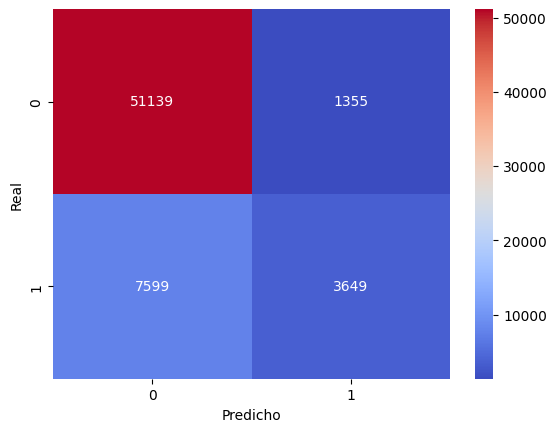

--------------------------------


In [10]:
arbol_decision = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train_scaled, y_train)

y_pred = arbol_decision.predict(X_test_scaled)

#Las metricas de cada modelo
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print ("Accuracy: ", acc)
print ("Precision: ", prec)
print ("Recall: ", rec)
print ("")
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()
print ("--------------------------------")

- La clase pobreza_multi está desbalanceada. Investigue el argumento class_weight='balanced' de sklearn para manejar este problema y aplíquelo si lo considera pertinente.

¿Podemos concluír con esto que el modelo tiene el mismo rendimiento para todos los grupos demográficos?


In [11]:

y.value_counts()

pobreza_multi
False    174979
True      37492
Name: count, dtype: int64

Hay muchos mas personas no pobres que personas pobres, por ende este modelo es menos preciso para la gente pobre (de hecho esto se puede ver en la matriz de confusion donde tomo mas falsos negativos que falsos positivos)

Accuracy:  0.7609425496532898
Precision:  0.4031459364986892
Recall:  0.7382645803698435



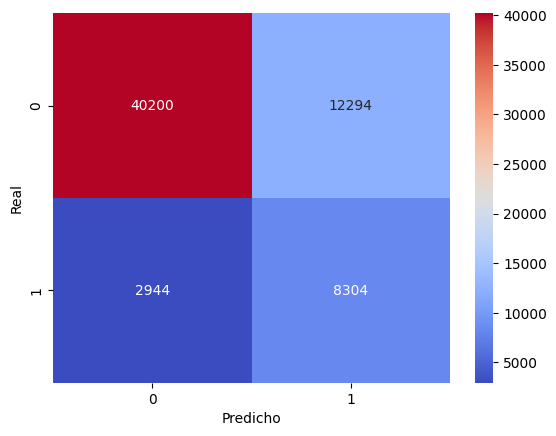

--------------------------------


In [12]:
arbol_decision = DecisionTreeClassifier(class_weight='balanced',max_depth=10, random_state=42).fit(X_train_scaled, y_train)

y_pred = arbol_decision.predict(X_test_scaled)

#Las metricas de cada modelo
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print ("Accuracy: ", acc)
print ("Precision: ", prec)
print ("Recall: ", rec)
print ("")
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()
print ("--------------------------------")

Es un poco mas preciso y tiene falsos positivos/negativos mas proporcionales, pero se pierde un poco de accuraracy y sacrificamos tener menos falsos negativos teniedendo mas falsos positivos

## Parte 3: Evalúe las predicciones del modelo mediante las métricas de Fairness de Aequitas.

### **Indicaciones**

Considere como atributos demográficos sensibles mínimos: trans, r3 (pertenencia a pueblo indígena), os1 (orientación sexual) y edad_cat.
Aequitas requiere que todas las variables sensibles estén binarizadas en grupos privilegiado / no privilegiado.

Para variables con más de dos categorías, cree una columna auxiliar que agrupe las categorías y justifique su decisión. Los grupos de referencia mínimos a considerar son a lo menos 2 de:

- trans: no trans como grupo privilegiado, trans como grupo no privilegiado.
- r3: no indígena como grupo privilegiado, indígena como grupo no privilegiado.
- os1: heterosexual como grupo privilegiado, otras orientaciones como grupo no privilegiado.
- edad_cat: cree la variable edad_cat con intervalos que usted considere privilegiado/no priviligiado según el contexto.

Asociadas a posibles discapacidades (revisar libro de códigos):

h7e: 1. No, ninguna dificultad, como grupo privilegiado. Los demás como no privilegiados.

h7f: 1. No, ninguna dificultad, como grupo privilegiado. Los demás, como no privilegiado.


Finalmente, reporte las métricas de False Negative Rate Parity y False Discovery Rate Parity.

¿Cuán justas se pueden considerar las predicciones del modelo para cada grupo, como relacionaría esto con los contenidos de clases?

In [13]:
### codigo aquí


df_test_og = df.loc[X_test.index].copy()
df_test_og

,area,p1,p2,p3,p4,p9,tot_per_h,edad,sexo,ind_hacina,...,v22,v23,v24,v24b,v27a,v27b,v29b,os1,trans,pobreza_multi
121556,Rural,Casa acceso directo,3,4,4,3,3,59,Mujer,1,...,Llave dentro vivienda,1,Solo generador propio,36000.0,3.0,1.0,1.0,Heterosexual,No,Pobre
86540,Urbano,Casa acceso directo,3,4,3,5,5,70,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,45000.0,4.0,3.0,1.0,Heterosexual,No,No pobre
90526,Urbano,Depto condominio,2,3,3,4,4,43,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,32000.0,3.0,2.0,1.0,Heterosexual,No,No pobre
209348,Urbano,Casa acceso directo,2,4,4,3,3,11,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,150000.0,2.0,2.0,1.0,Heterosexual,No,No pobre
177936,Urbano,Casa acceso directo,3,4,4,4,4,15,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,56000.0,3.0,2.0,1.0,Heterosexual,No,No pobre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42932,Urbano,Casa acceso directo,3,3,2,4,4,62,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,48000.0,4.0,2.0,1.0,Heterosexual,No,No pobre
154097,Urbano,Depto condominio,1,4,4,3,3,47,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,60000.0,3.0,2.0,1.0,Heterosexual,No,No pobre
178565,Urbano,Depto acceso directo,1,4,4,1,1,30,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,30000.0,1.0,1.0,1.0,Heterosexual,No,No pobre
120466,Urbano,Casa acceso directo,2,3,3,7,7,14,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,65000.0,6.0,2.0,1.0,Heterosexual,No,No pobre


In [14]:
df_aequitas = pd.DataFrame({'label_value': y_test.astype(int), 'score': y_pred.astype(int)})

df_aequitas

df_aequitas['trans'] = df_test_og['trans'].apply(lambda x: 'No trans' if x == 'No' else 'Trans/otro')

df_aequitas['r3'] = df_test_og['r3'].apply(lambda x: 'No Indigena' if x != 'Indígena' else 'Indigena')

df_aequitas['os1'] = df_test_og['os1'].apply(lambda x: 'Heterosexual' if x == 'Heterosexual' else 'Otro')

# Sea el rango de 24 a 60 años la edad privilegiada laboral (por salida de estudios a los 24 y jubilacion a los 60)
df_aequitas['edad_cat'] = df_test_og['edad'].apply(lambda x: '24-60' if  24 <= x <= 60 else '<24 o >60')

df_aequitas['h7e'] = df_test_og['h7e'].apply(lambda x: 'No discapacitado' if  x == 1 else 'Discapacitado')

df_aequitas['h7f'] = df_test_og['h7f'].apply(lambda x: 'No discapacitado' if  x == 1 else 'Discapacitado')

df_aequitas

,label_value,score,trans,r3,os1,edad_cat,h7e,h7f
121556,1,1,No trans,No Indigena,Heterosexual,24-60,No discapacitado,No discapacitado
86540,0,0,No trans,No Indigena,Heterosexual,<24 o >60,No discapacitado,No discapacitado
90526,0,0,No trans,No Indigena,Heterosexual,24-60,No discapacitado,No discapacitado
209348,0,0,No trans,Indigena,Heterosexual,<24 o >60,No discapacitado,No discapacitado
177936,0,0,No trans,No Indigena,Heterosexual,<24 o >60,No discapacitado,No discapacitado
...,...,...,...,...,...,...,...,...
42932,0,0,No trans,No Indigena,Heterosexual,<24 o >60,No discapacitado,No discapacitado
154097,0,0,No trans,No Indigena,Heterosexual,24-60,No discapacitado,No discapacitado
178565,0,0,No trans,No Indigena,Heterosexual,24-60,No discapacitado,No discapacitado
120466,0,1,No trans,No Indigena,Heterosexual,<24 o >60,No discapacitado,No discapacitado


In [15]:
group = Group()

x_tab, _ = group.get_crosstabs(df_aequitas)

# Codigo taller formativo 2
absolute_metrics = group.list_absolute_metrics(x_tab)

absolute_xtab = x_tab[
    ["attribute_name", "attribute_value", "group_size", "total_entities"] + absolute_metrics
]
absolute_xtab

,attribute_name,attribute_value,group_size,total_entities,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,ppr,pprev,prev
0,trans,No trans,63715,63742,0.760920,0.738349,0.765756,0.068225,0.596853,0.234244,0.261651,0.931775,0.403147,0.999757,0.323205,0.176473
1,trans,Trans/otro,27,63742,0.814815,0.500000,0.869565,0.090909,0.600000,0.130435,0.500000,0.909091,0.400000,0.000243,0.185185,0.148148
2,r3,Indigena,8945,63742,0.697149,0.776465,0.672573,0.093368,0.576437,0.327427,0.223535,0.906632,0.423563,0.188319,0.433650,0.236557
3,r3,No Indigena,54797,63742,0.771356,0.729413,0.779744,0.064893,0.601591,0.220256,0.270587,0.935107,0.398409,0.811681,0.305108,0.166651
4,os1,Heterosexual,62240,63742,0.760492,0.740188,0.764841,0.067835,0.597265,0.235159,0.259812,0.932165,0.402735,0.979804,0.324261,0.176430
5,os1,Otro,1502,63742,0.779627,0.659176,0.805668,0.083794,0.576923,0.194332,0.340824,0.916206,0.423077,0.020196,0.276964,0.177763
6,edad_cat,24-60,30962,63742,0.771817,0.724900,0.781395,0.067051,0.596329,0.218605,0.275100,0.932949,0.403671,0.457617,0.304438,0.169530
7,edad_cat,<24 o >60,32780,63742,0.750671,0.749958,0.750831,0.069419,0.597297,0.249169,0.250042,0.930581,0.402703,0.542383,0.340818,0.183008
8,h7e,Discapacitado,2517,63742,0.701629,0.690909,0.705439,0.134742,0.545364,0.294561,0.309091,0.865258,0.454636,0.048694,0.398490,0.262217
9,h7e,No discapacitado,61225,63742,0.763381,0.741216,0.768015,0.065818,0.599490,0.231985,0.258784,0.934182,0.400510,0.951306,0.320049,0.172936


In [16]:
# Me guie  y saque codigo a traves de https://github.com/dssg/aequitas/blob/master/docs/source/examples/compas_demo.ipynb y la documentacion de aequitas para hacer lo restante de la parte 3
bias = Bias()

bdf = bias.get_disparity_predefined_groups(absolute_xtab, original_df=df_aequitas, ref_groups_dict={'trans': 'No trans', 'r3': 'No Indigena', 'os1': 'Heterosexual', 'edad_cat': '24-60', 'h7e': 'No discapacitado', 'h7f': 'No discapacitado'}, check_significance=True, mask_significance=True)

bdf

,attribute_name,attribute_value,group_size,total_entities,accuracy,tpr,tnr,for,fdr,fpr,...,pprev_significance,precision_disparity,precision_ref_group_value,precision_significance,tnr_disparity,tnr_ref_group_value,tnr_significance,tpr_disparity,tpr_ref_group_value,tpr_significance
0,trans,No trans,63715,63742,0.760920,0.738349,0.765756,0.068225,0.596853,0.234244,...,False,1.000000,No trans,False,1.000000,No trans,False,1.000000,No trans,False
1,trans,Trans/otro,27,63742,0.814815,0.500000,0.869565,0.090909,0.600000,0.130435,...,False,0.992195,No trans,False,1.135564,No trans,False,0.677186,No trans,False
2,r3,Indigena,8945,63742,0.697149,0.776465,0.672573,0.093368,0.576437,0.327427,...,True,1.063136,No Indigena,True,0.862556,No Indigena,True,1.064507,No Indigena,True
3,r3,No Indigena,54797,63742,0.771356,0.729413,0.779744,0.064893,0.601591,0.220256,...,False,1.000000,No Indigena,False,1.000000,No Indigena,False,1.000000,No Indigena,False
4,os1,Heterosexual,62240,63742,0.760492,0.740188,0.764841,0.067835,0.597265,0.235159,...,False,1.000000,Heterosexual,False,1.000000,Heterosexual,False,1.000000,Heterosexual,False
5,os1,Otro,1502,63742,0.779627,0.659176,0.805668,0.083794,0.576923,0.194332,...,True,1.050509,Heterosexual,False,1.053379,Heterosexual,False,0.890553,Heterosexual,False
6,edad_cat,24-60,30962,63742,0.771817,0.724900,0.781395,0.067051,0.596329,0.218605,...,False,1.000000,24-60,False,1.000000,24-60,False,1.000000,24-60,False
7,edad_cat,<24 o >60,32780,63742,0.750671,0.749958,0.750831,0.069419,0.597297,0.249169,...,True,0.997603,24-60,False,0.960886,24-60,False,1.034568,24-60,False
8,h7e,Discapacitado,2517,63742,0.701629,0.690909,0.705439,0.134742,0.545364,0.294561,...,True,1.135142,No discapacitado,True,0.918522,No discapacitado,True,0.932129,No discapacitado,True
9,h7e,No discapacitado,61225,63742,0.763381,0.741216,0.768015,0.065818,0.599490,0.231985,...,False,1.000000,No discapacitado,False,1.000000,No discapacitado,False,1.000000,No discapacitado,False


In [17]:
fairness = Fairness()
fdf = fairness.get_group_value_fairness(bdf)

parity_determinations = fairness.list_parities(fdf)

fdf

,attribute_name,attribute_value,group_size,total_entities,accuracy,tpr,tnr,for,fdr,fpr,...,FNR Parity,TPR Parity,TNR Parity,NPV Parity,Precision Parity,TypeI Parity,TypeII Parity,Equalized Odds,Unsupervised Fairness,Supervised Fairness
0,trans,No trans,63715,63742,0.760920,0.738349,0.765756,0.068225,0.596853,0.234244,...,True,True,True,True,True,True,True,True,True,True
1,trans,Trans/otro,27,63742,0.814815,0.500000,0.869565,0.090909,0.600000,0.130435,...,False,False,True,True,True,False,False,False,False,False
2,r3,Indigena,8945,63742,0.697149,0.776465,0.672573,0.093368,0.576437,0.327427,...,True,True,True,True,True,False,False,False,False,False
3,r3,No Indigena,54797,63742,0.771356,0.729413,0.779744,0.064893,0.601591,0.220256,...,True,True,True,True,True,True,True,True,True,True
4,os1,Heterosexual,62240,63742,0.760492,0.740188,0.764841,0.067835,0.597265,0.235159,...,True,True,True,True,True,True,True,True,True,True
5,os1,Otro,1502,63742,0.779627,0.659176,0.805668,0.083794,0.576923,0.194332,...,False,True,True,True,True,True,False,True,False,False
6,edad_cat,24-60,30962,63742,0.771817,0.724900,0.781395,0.067051,0.596329,0.218605,...,True,True,True,True,True,True,True,True,True,True
7,edad_cat,<24 o >60,32780,63742,0.750671,0.749958,0.750831,0.069419,0.597297,0.249169,...,True,True,True,True,True,True,True,True,True,True
8,h7e,Discapacitado,2517,63742,0.701629,0.690909,0.705439,0.134742,0.545364,0.294561,...,True,True,True,True,True,False,False,False,False,False
9,h7e,No discapacitado,61225,63742,0.763381,0.741216,0.768015,0.065818,0.599490,0.231985,...,True,True,True,True,True,True,True,True,True,True


In [18]:
cols = ['attribute_name', 'attribute_value', 'fnr', 'fnr_disparity', 'FNR Parity', 'fdr', 'fdr_disparity', 'FDR Parity']
fdf_limpio = fdf[cols]

fdf_limpio

,attribute_name,attribute_value,fnr,fnr_disparity,FNR Parity,fdr,fdr_disparity,FDR Parity
0,trans,No trans,0.261651,1.000000,True,0.596853,1.000000,True
1,trans,Trans/otro,0.500000,1.910945,False,0.600000,1.005272,True
2,r3,Indigena,0.223535,0.826111,True,0.576437,0.958188,True
3,r3,No Indigena,0.270587,1.000000,True,0.601591,1.000000,True
4,os1,Heterosexual,0.259812,1.000000,True,0.597265,1.000000,True
5,os1,Otro,0.340824,1.311808,False,0.576923,0.965942,True
6,edad_cat,24-60,0.275100,1.000000,True,0.596329,1.000000,True
7,edad_cat,<24 o >60,0.250042,0.908912,True,0.597297,1.001622,True
8,h7e,Discapacitado,0.309091,1.194399,True,0.545364,0.909714,True
9,h7e,No discapacitado,0.258784,1.000000,True,0.599490,1.000000,True


## Parte 4: Aplique el algoritmo EqOddsPostProcessing sobre las predicciones del modelo de la pregunta 1. Obtenga las predicciones modificadas y evalúelas.

#### Indicaciones:

- Obtenga tanto las instancias de BinaryLabelDatasetMetric como de ClassificationMetric y calcule al menos una métrica de Fairness.

- comentar brevemente los resultados obtenidos, y evaluar los cambios en las métricas de Fairness. Reflexionar sobre los beneficios y limitaciones


In [19]:
# taller 3
def get_aif_metrics(attr, df, label_names):
    """
    Construye un BinaryLabelDataset de AIF360 a partir de un DataFrame
    y retorna las métricas de grupo junto con el dataset formateado.

    Parámetros
    ----------
    attr : str
        Nombre de la columna del atributo protegido (debe estar codificado como 0/1,
        donde 1 = grupo privilegiado).
    df : pd.DataFrame
        DataFrame que incluye features, atributo protegido y etiqueta.
    label_names : list[str]
        Lista con el nombre de la columna de etiqueta (p.ej. ["income"]).

    Retorna
    -------
    metric : BinaryLabelDatasetMetric
        Métricas de grupo sobre el dataset.
    dt : BinaryLabelDataset
        Dataset en formato AIF360.
    """
    privileged_groups   = [{attr: 1}]
    unprivileged_groups = [{attr: 0}]

    attributes_params = dict(protected_attribute_names=[attr], label_names=label_names)
    dt = BinaryLabelDataset(
        df=df, **attributes_params, favorable_label=1, unfavorable_label=0
    )

    metric = BinaryLabelDatasetMetric(
        dt, unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups
    )

    return metric, dt

In [20]:
# taller 3
df_test_pred = X_test.copy()
df_test_pred["pobreza_multi"] = y_pred          # predicciones del modelo base

df_test = X_test.copy()
df_test["pobreza_multi"] = y_test.values        # etiquetas reales

In [21]:
# modificado del taller formativo 3
def aplicar_EqOddsPostProcessing(group, df_test_pred, df_test):
    """
    Aplica EqOddsPostprocessing de AIF360 sobre las predicciones de un modelo
    para un atributo protegido dado, e imprime las métricas de fairness resultantes.

    Parámetros
    ----------
    group : str
        Nombre del atributo protegido (columna en df_test_pred y df_test,
        codificado como 0/1 donde 1 = privilegiado).
    df_test_pred : pd.DataFrame
        DataFrame del conjunto de test con las predicciones del modelo.
    df_test : pd.DataFrame
        DataFrame del conjunto de test con las etiquetas reales.
    """
    privileged_groups   = [{group: 1}]
    unprivileged_groups = [{group: 0}]

    # Convertimos a formato AIF360
    instanciabd_pred, test_pred_aifdf = get_aif_metrics(group, df_test_pred, ["pobreza_multi"])
    instanciabd_true, test_aifdf      = get_aif_metrics(group, df_test,      ["pobreza_multi"])

    # Instanciamos y ajustamos el algoritmo de posprocesamiento
    roc = EqOddsPostprocessing(
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
        seed=103,
    )
    roc.fit(test_aifdf, test_pred_aifdf)

    # Generamos las predicciones corregidas
    corrected_pred = roc.predict(test_pred_aifdf)

    # Calculamos métricas de fairness sobre las predicciones corregidas
    cm = ClassificationMetric(
        test_aifdf,
        corrected_pred,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    
    # creamos una nueva instancia
    # ya que bldm_pred contiene las metricas sin aplicar el filtro
    bldm_corrected = BinaryLabelDatasetMetric(
        corrected_pred, 
        unprivileged_groups=unprivileged_groups, 
        privileged_groups=privileged_groups
    )

    print(f"  Equal opportunity difference        : {cm.equal_opportunity_difference():.4f}")
    print(f"  Error rate difference               : {cm.error_rate_difference():.4f}")
    print(f"  FNR grupo privilegiado              : {cm.false_negative_rate(privileged=True):.4f}")
    print(f"  FNR grupo no privilegiado           : {cm.false_negative_rate(privileged=False):.4f}")
    print(f"  FNR ratio (no-priv / priv)          : {cm.false_negative_rate_ratio():.4f}")
    print(f"  FPR grupo privilegiado              : {cm.false_positive_rate(privileged=True):.4f}")
    print(f"  FPR grupo no privilegiado           : {cm.false_positive_rate(privileged=False):.4f}")
    print(f"  FPR ratio (no-priv / priv)          : {cm.false_positive_rate_ratio():.4f}")

    # evaluar los cambios
    print(f"Metrica de BinaryLabelDatasetMetric: ")
    print(f"Disparate Impact: {bldm_corrected.disparate_impact():.4f}")
    print("Evaluacion:")
    print(f"  Accuracy original: {accuracy_score(test_aifdf.labels, test_pred_aifdf.labels):.4f}")
    print(f"  Accuracy filtrado: {accuracy_score(test_aifdf.labels, corrected_pred.labels):.4f}")

In [22]:
aplicar_EqOddsPostProcessing("r3_Indígena", df_test_pred, df_test)

  Equal opportunity difference        : 0.0026
  Error rate difference               : 0.0048
  FNR grupo privilegiado              : 0.2377
  FNR grupo no privilegiado           : 0.2351
  FNR ratio (no-priv / priv)          : 0.9890
  FPR grupo privilegiado              : 0.3235
  FPR grupo no privilegiado           : 0.3225
  FPR ratio (no-priv / priv)          : 0.9971
Metrica de BinaryLabelDatasetMetric: 
Disparate Impact: 0.9274
Evaluacion:
  Accuracy original: 0.7609
  Accuracy filtrado: 0.6927


## **Parte 5** (bonus +5 decimas) :  

Aplique el algoritmo de Reweighing sobre los datos de entrenamiento. Compare las métricas de Fairness para los datos de entrenamiento antes y después de aplicar Reweighing.

Luego, entrene un Arbol de decisión utilizando los datos de entrenamiento modificados y obtenga las métricas de Fairness de las predicciones de dicho modelo.

Analice cómo varió el *accuracy* del modelo respecto al original y las métricas de Fairness y reflexione sobre las implicancias sociales de estas decisiones.

### Indicaciones:
Puedes considerar los grupos priviligiados/no priviligiados mencionados en la parte 3. Considere al menos 2.

In [23]:
### codigo aquí

# `Instrucciones del informe`

## `Estructura y puntaje`

| Sección | Contenido esperado | Puntaje |
|---|---|---|
| Objetivos y métodos | Reformulación propia de qué se buscaba explorar y los métodos que usaron para hacerlo. Utilicen la información de la [**Metodología de Diseño Muestral CASEN 2024**](https://drive.google.com/file/d/1VafJ57Ta6_gwUM-8sir6PAw5DVuBh0rq/view?usp=sharing) como referencia. | 10% |
| Resultados / Fragmentos de código | Métricas antes y después de la mitigación, fragmentos de código de ser necesario, visualizaciones de sesgos. | 45% |
| Reflexión | Justificación de herramientas utilizadas y respuestas a preguntas guiadas. Se espera que la reflexión acompañe los resultados a lo largo del informe, no que sea una sección aparte. Consideren incluir un cierre o conclusión al final. | 30% |
| Código ordenado y correcto | El código está bien implementado, es legible y cuenta con documentación mínima adecuada. | 15% |

## `Temas formales`

**Modalidad:** Deben realizar el taller en grupos de 2 o 3 personas.

**Fecha límite de entrega:** Martes 21 de abril, hasta las 11:59 a.m. (hora local).

**Formato de entrega:** El trabajo debe entregarse a través de Canvas. Tanto el Jupyter como el informe deben entregarse en formato PDF.

**Extensión:** Máximo 4 planas.

**Formato del documento:**
- Citas: APA 7
- Formato: dos columnas
- Fuente: Times New Roman, tamaño 12
- Interlineado: 1,5

No es necesario justificar resultados o métodos en el Jupyter, pero el informe sí debe incluir los resultados y las reflexiones planteadas en él. Toda métrica o visualización que no esté acompañada de una explicación no será considerada en la evaluación.

## `Recomendaciones`

Asistan a los talleres formativos, revisen los ejemplos de código y consulten sus dudas con sus ayudantes :D.

## `Importante`

**Lean la rúbrica antes de escribir su informe.**

## `Integridad académica y uso de IA`

El uso de asistentes de IA para escribir código no está prohibido, pero debe ser documentado. La redacción del informe sigue los lineamientos de integridad académica del curso.

No está permitida la copia completa o parcial entre distintos grupos. Entregar el enunciado directamente a una IA y pedirle que complete la tarea tampoco está permitido. Cualquier uso no documentado o irresponsable de IA, o plagio, será considerado una falta a la integridad académica.

Si tienen dudas sobre el uso de IA o la citación de código externo, no duden en preguntar. Pueden usar libremente los códigos de los talleres formativos. <3